# Seesaw Figures 1 and 2

This notebook reproduces the primary Seesaw paper figures from immutable W&B
run IDs in `run_manifest.json`. It does **not** use the exploratory notebooks
that produced the paper graphics.

The shared module validates each run's state, group, Git metadata, and logged
configuration, then reads its complete W&B history artifact. Each trace is
plotted once without Seaborn aggregation. Set `WANDB_API_KEY` or run
`wandb login` before executing.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / "reproducibility").is_dir():
    repo_root = repo_root.parent
assert (repo_root / "reproducibility").is_dir(), "Run from the repository root or reproducibility/"
sys.path.insert(0, str(repo_root))

from reproducibility.reproduce_figures import reproduce

repro_dir = repo_root / "reproducibility"
output_dir = repro_dir / "outputs"
cache_dir = repro_dir / "cache"
manifest_path = repro_dir / "run_manifest.json"

## Validate, download, and plot

The first execution downloads the full history artifacts. Later executions use
the local ignored cache but still validate the live W&B run metadata against
the manifest.

In [2]:
endpoints = reproduce(
    manifest_path=manifest_path,
    output_dir=output_dir,
    cache_dir=cache_dir,
    figures=("figure_1", "figure_2"),
)
endpoints

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


,figure,run_id,model,initial_batch_size,learning_rate,role,final_tokens,final_steps,final_validation_loss,git_commit,alpha,beta
0,figure_1,nj1u496n,150M,128,0.003,Cosine,3300130816,25178,3.028236,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
1,figure_1,gey9bxyb,150M,128,0.003,Seesaw,3300887552,15524,3.020843,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
2,figure_1,o9ta07dz,150M,256,0.003,Cosine,3300130816,12589,3.035399,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
3,figure_1,0nfs2729,150M,256,0.003,Seesaw,3300596736,7756,3.034697,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
4,figure_1,rf3zo4ho,150M,512,0.003,Cosine,3300392960,6295,3.069617,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
5,figure_1,s2bflp18,150M,512,0.003,Seesaw,3302964224,3877,3.068772,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
6,figure_1,0je08kka,300M,128,0.001,Cosine,6600130560,50355,2.853113,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
7,figure_1,q2hwivdd,300M,128,0.001,Seesaw,6600698880,31046,2.845271,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
8,figure_1,cj8la1js,300M,256,0.010,Cosine,6600261632,25178,2.859199,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN
9,figure_1,7g7lspre,300M,256,0.010,Seesaw,6600976384,15511,2.856142,ff609819f24df19ac9b943f96ff5f4ea586534ca,NaN,NaN


## Figure 1: Seesaw versus cosine

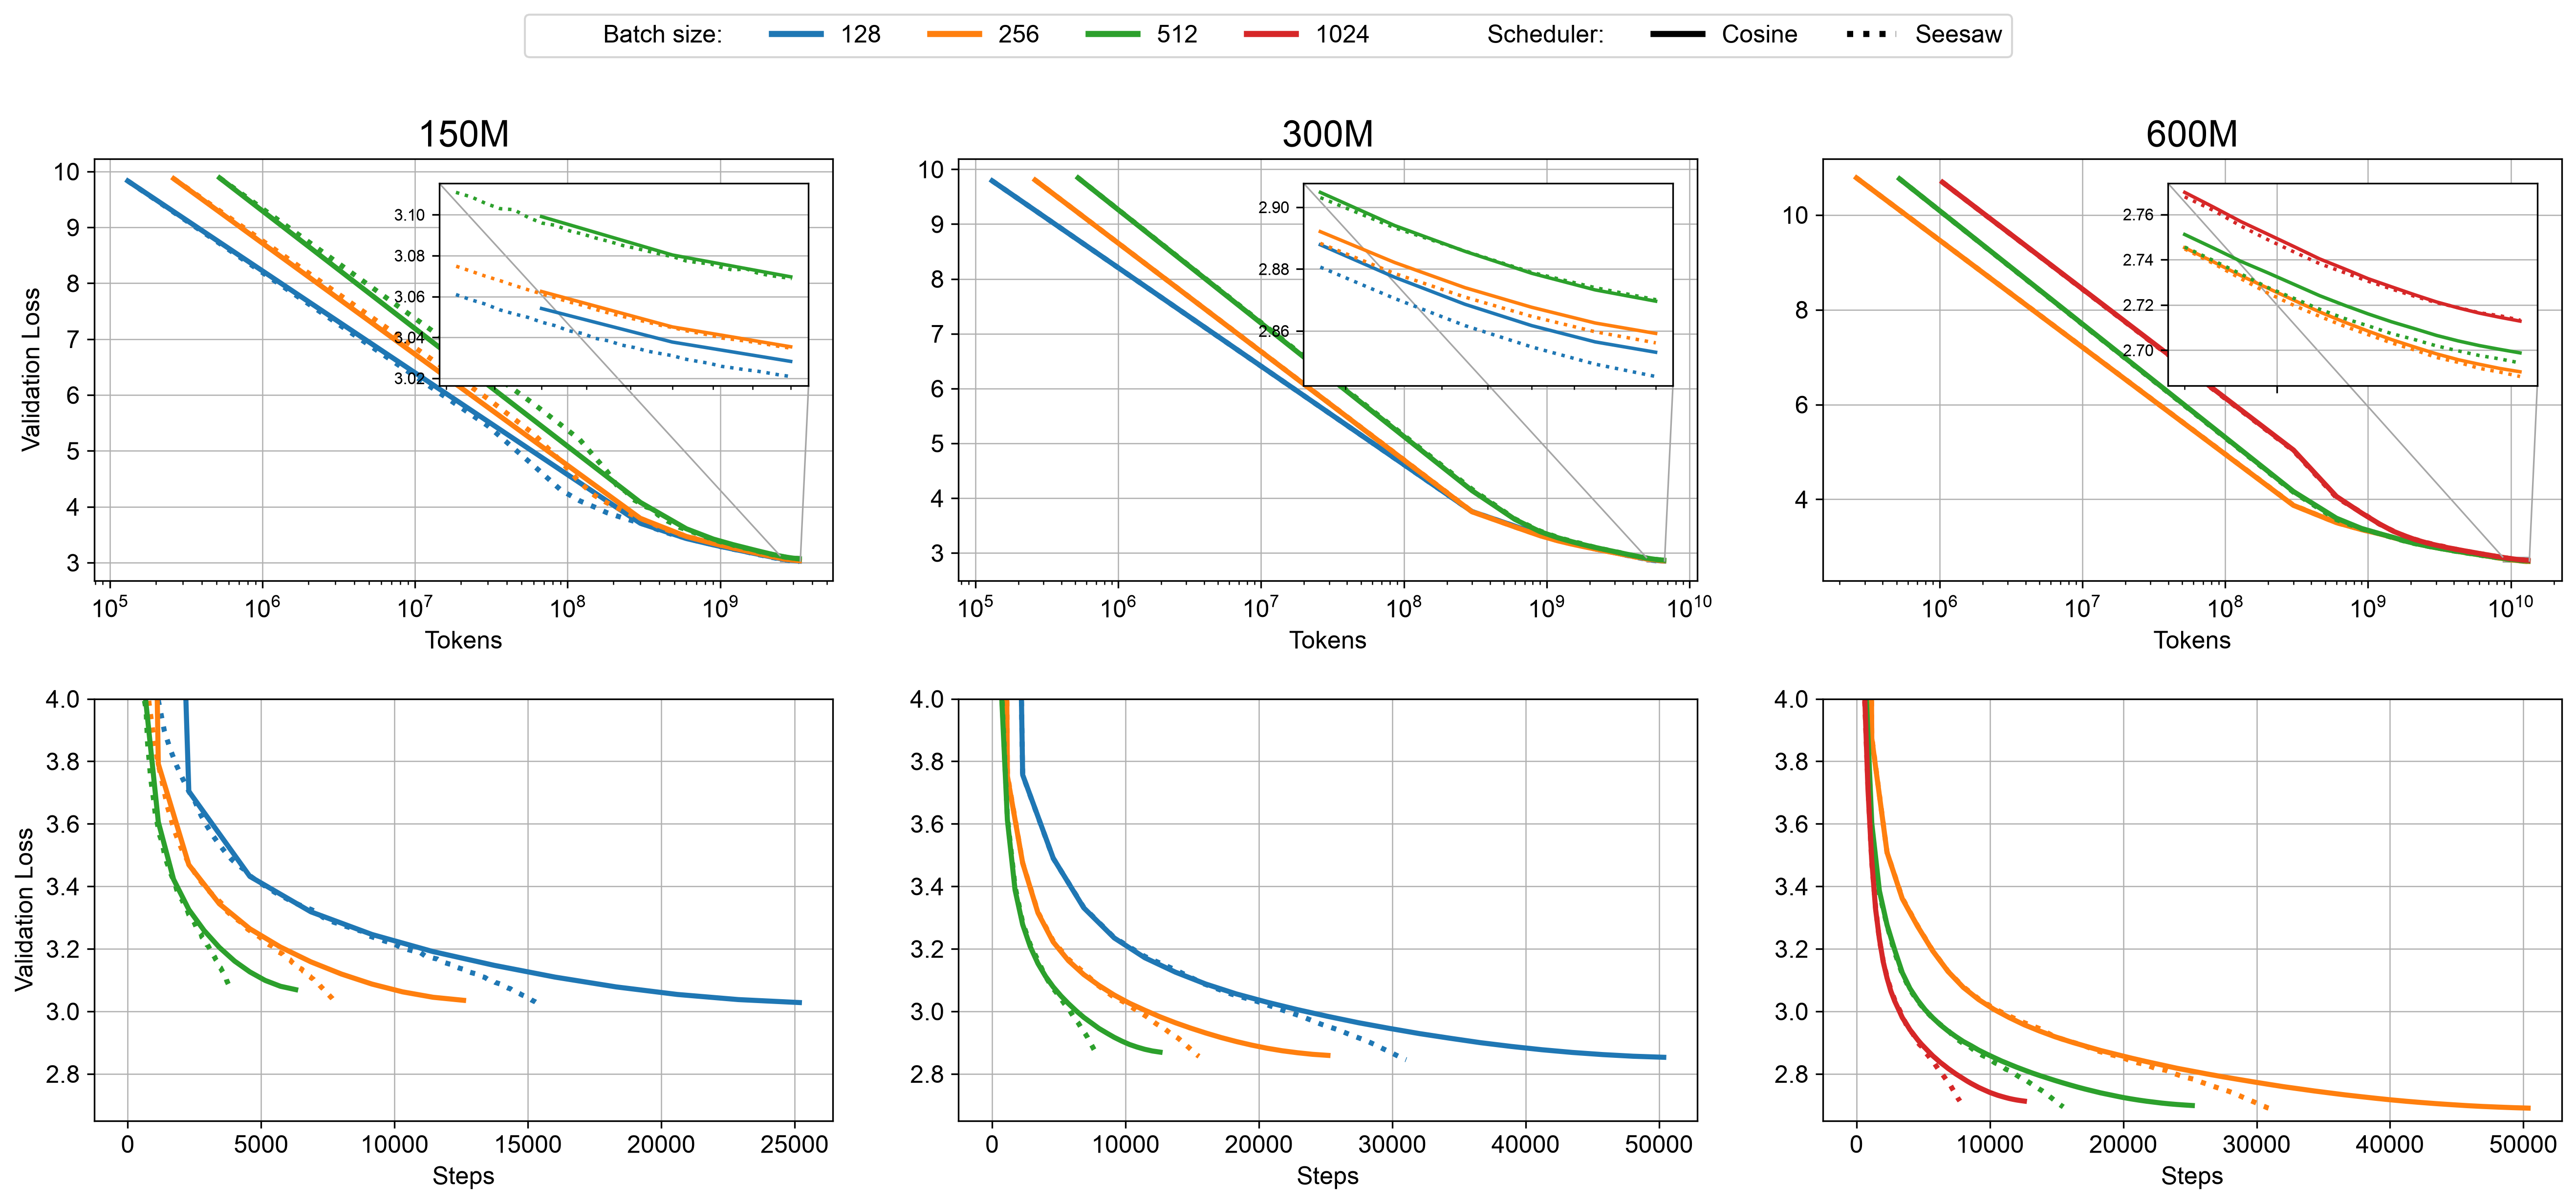

In [3]:
from IPython.display import Image, display

display(Image(filename=output_dir / "figure_1_main.png", width=1100))

## Figure 2: equivalence-family schedules

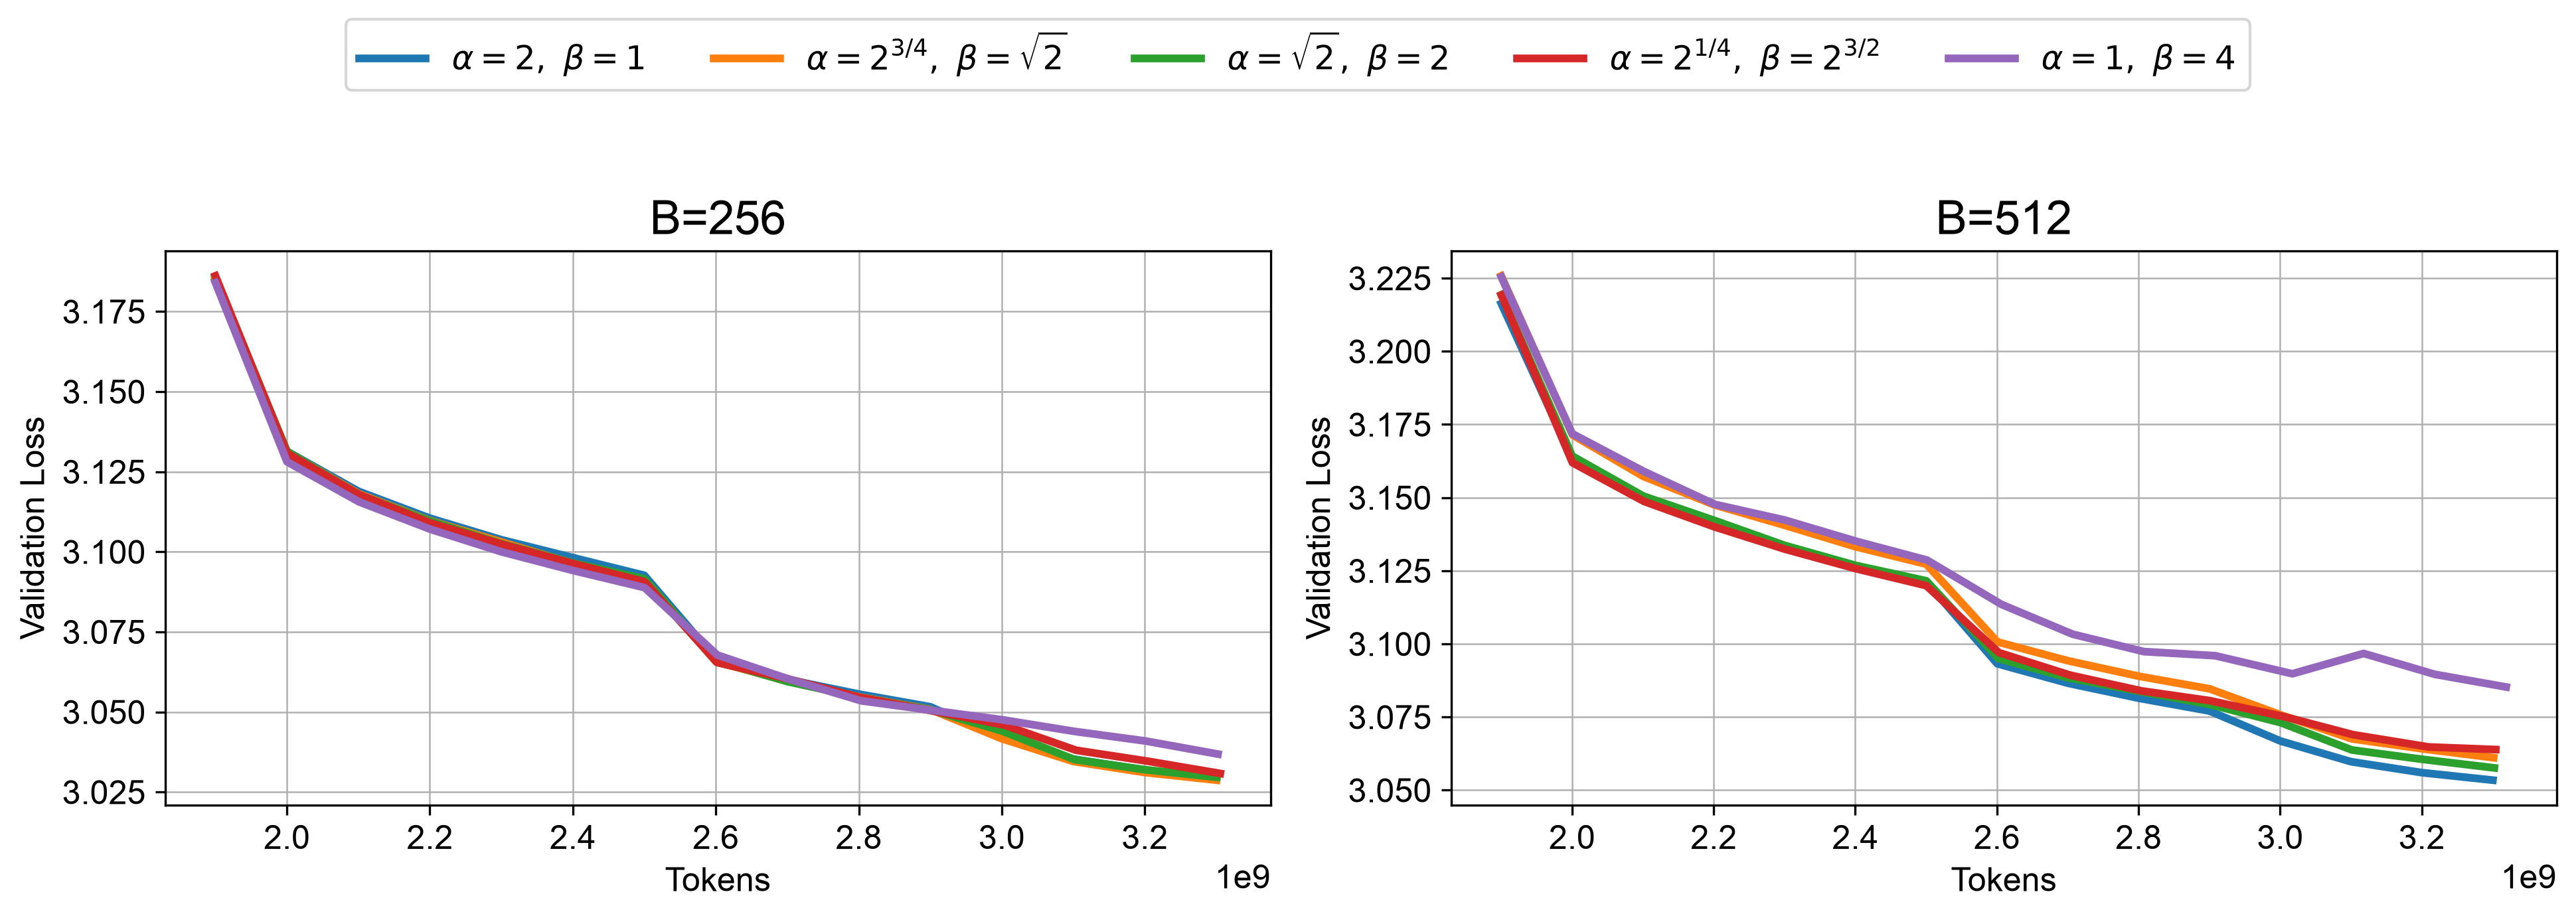

In [4]:
display(Image(filename=output_dir / "figure_2_equivalence.png", width=1100))

## Logged sequential-step reductions

These are optimizer-step reductions at equal token budgets, not measured
wall-clock speedups.

In [5]:
import pandas as pd

pd.read_csv(output_dir / "figure_1_step_reductions.csv")

,model,initial_batch_size,cosine_steps,seesaw_steps,step_reduction_fraction
0,150M,128,25178,15524,0.383430
1,150M,256,12589,7756,0.383907
2,150M,512,6295,3877,0.384114
3,300M,128,50355,31046,0.383457
4,300M,256,25178,15511,0.383946
5,300M,512,12589,7752,0.384224
6,600M,256,50355,31021,0.383954
7,600M,512,25178,15502,0.384304
8,600M,1024,12589,7751,0.384304


The command-line entry point can also reproduce the supplied
large-batch and weight-decay plots:

```bash
python reproducibility/reproduce_figures.py
```

See `reproducibility/README.md` and `AUDIT.md` for selection details,
provenance limitations, and identified issues.